<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/Layer%201/Phase%203/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, let's import the necessary libraries, define a simple quadratic function and its derivative.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function we want to minimize (e.g., a simple quadratic function)
def f(x):
    return x**2 - 4*x + 5

# Define the derivative of the function
def df(x):
    return 2*x - 4

Here's a Python example demonstrating gradient descent to find the minimum of a simple function. I'll use a quadratic function for this example.

Great! The gradient descent algorithm successfully found the minimum of the function `f(x) = x^2 - 4x + 5`.

*    The code first defined the function `f(x)` and its derivative `df(x)`.
*    Then, it ran the gradient descent for 50 iterations with a learning rate of 0.1, starting at `x = 0.0`.
*    As you can see from the output, the algorithm converged to` x = 2.0000` with a minimum function value of `1.0000`. This is the correct global minimum for this quadratic function

Now, let's implement the gradient descent algorithm.

In [2]:
# Gradient Descent parameters
learning_rate = 0.1
iterations = 50
initial_x = 0.0 # Starting point

# Lists to store the history of x values and function values
x_history = [initial_x]
f_history = [f(initial_x)]

current_x = initial_x

for i in range(iterations):
    gradient = df(current_x)
    current_x = current_x - learning_rate * gradient
    x_history.append(current_x)
    f_history.append(f(current_x))

print(f"Minimum found at x = {current_x:.4f}")
print(f"Minimum function value = {f(current_x):.4f}")

for i in range(3):
  print(f"point x: {x_history[i]} point f(x): {f_history[i]}")

Minimum found at x = 2.0000
Minimum function value = 1.0000
point x: 0.0 point f(x): 5.0
point x: 0.4 point f(x): 3.56
point x: 0.7200000000000001 point f(x): 2.6384


Finally, let's visualize the process of gradient descent converging to the minimum.

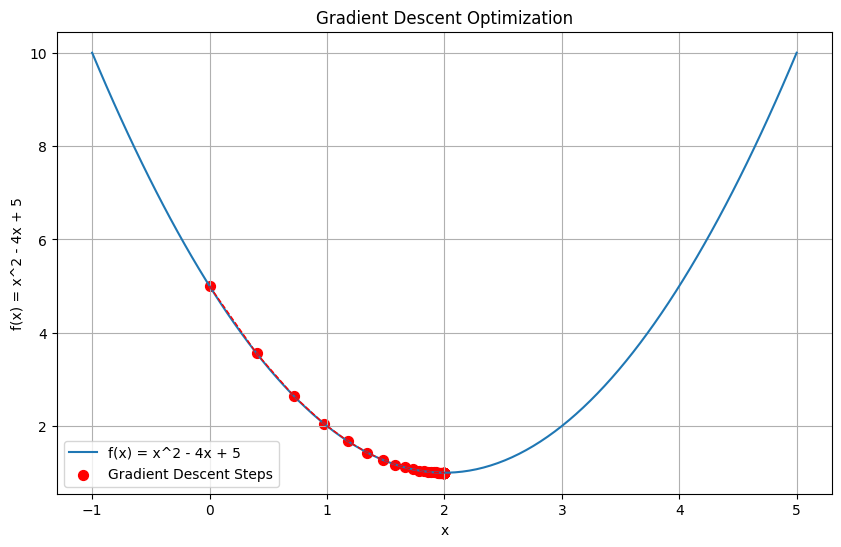

In [3]:
x_values = np.linspace(-1, 5, 100)
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = x^2 - 4x + 5')
plt.scatter(x_history, f_history, color='red', marker='o', s=50, label='Gradient Descent Steps')
plt.plot(x_history, f_history, color='red', linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel('f(x) = x^2 - 4x + 5')
plt.title('Gradient Descent Optimization')
plt.legend()
plt.grid(True)
plt.show()

The plot visualizes this process: the blue curve is the function `f(x)`, and the red dots and dashed line show the steps taken by the gradient descent algorithm, iteratively moving towards the minimum point at `x=2, f(x)=1`.

We have successfully demonstrated gradient descent with a Python example, minimizing a quadratic function and visualizing its convergence. The algorithm accurately found the minimum of` f(x) = x^2 - 4x + 5` at `x = 2` with a minimum value of `1`.

**SGD — Stochastic Gradient Descent**

The simplest possible update rule. Compute the gradient, step in the opposite direction.

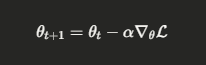


Where θ is the weights, α is the learning rate, and ∇L is the gradient of the loss.

The "stochastic" part means you don't compute the gradient over the whole dataset — you estimate it from a small random batch. This is why every epoch shuffles the data and processes it in mini-batches.

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# Simple model
model = nn.Linear(2, 1)

# SGD optimizer — just needs parameters and learning rate
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

X = torch.randn(32, 2)
y = torch.randn(32, 1)

# The update loop — same 5 lines every time
optimizer.zero_grad()        # clear old gradients
pred = model(X)              # forward pass
loss = nn.MSELoss()(pred, y) # compute loss
loss.backward()              # compute gradients
optimizer.step()             # update weights

# What optimizer.step() does under the hood for SGD:
# for each parameter p:
#   p.data -= lr * p.grad

# Manually verifying:
w_before = model.weight.data.clone()
grad_before = model.weight.grad.clone()

# After step: w_new = w_old - lr * grad
w_expected = w_before - 0.1 * grad_before
#print(f"Weight before:  {w_expected}")
# (already stepped above, so let's just show the math holds)
print(f"Gradient:       {grad_before}")
print(f"LR * gradient:  {0.1 * grad_before}")
print(f"Weight after:   {model.weight.data}")

Gradient:       tensor([[0.9211, 0.6824]])
LR * gradient:  tensor([[0.0921, 0.0682]])
Weight after:   tensor([[0.4485, 0.5187]])


**SGD's problem:** The gradient direction from a single batch is noisy. The true gradient (over all data) points smoothly downhill, but the mini-batch gradient has random fluctuations. With a fixed learning rate, SGD oscillates — especially in directions where the loss surface curves steeply.

**Momentum — SGD with memory**

Momentum fixes SGD's oscillation problem by accumulating a "velocity" — a running average of past gradients. Instead of jumping at every noisy gradient, momentum builds up speed in consistent directions and dampens oscillations.

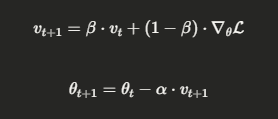


Where v is the velocity (exponential moving average of gradients) and β is the momentum coefficient (typically 0.9). If gradients consistently point the same direction, velocity builds up and steps get larger. If gradients flip direction (oscillation), they cancel out in the velocity.

In [5]:
# SGD with momentum
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# What momentum=0.9 means:
# v = 0.9 * v_prev + 0.1 * gradient
# New velocity is 90% old velocity + 10% new gradient signal
# This smooths out the noisy gradient estimates

# Implementing momentum manually to see what PyTorch does:
lr, beta = 0.01, 0.9
params = list(model.parameters())
velocities = [torch.zeros_like(p) for p in params]
print(f"params: {params}")
for step in range(5):
    optimizer_manual_zero = [p.grad.zero_() if p.grad is not None else None for p in params]
    pred = model(X)
    loss = nn.MSELoss()(pred, y)
    loss.backward()
    valocity_hist=[]
    with torch.no_grad():
        for i, p in enumerate(params):
            velocities[i] = beta * velocities[i] + (1 - beta) * p.grad
            p.data -= lr * velocities[i]
        valocity_hist.append(velocities[i])

    print(f"\nStep {step+1} | loss = {loss.item():.4f} | Velocity: {valocity_hist}")


params: [Parameter containing:
tensor([[0.4485, 0.5187]], requires_grad=True), Parameter containing:
tensor([-0.1025], requires_grad=True)]

Step 1 | loss = 1.2997 | Velocity: [tensor([-0.0516])]

Step 2 | loss = 1.2985 | Velocity: [tensor([-0.0979])]

Step 3 | loss = 1.2962 | Velocity: [tensor([-0.1394])]

Step 4 | loss = 1.2930 | Velocity: [tensor([-0.1765])]

Step 5 | loss = 1.2889 | Velocity: [tensor([-0.2096])]


**Intuition:** Think of a ball rolling down a hill. Without momentum it stops instantly when the slope flattens. With momentum it keeps rolling through flat regions and small bumps. This is why momentum converges faster than plain SGD on most problems.

**Adam — Adaptive Moment Estimation**

Adam is the optimizer you'll use for virtually all LLM fine-tuning. It combines momentum with a second trick: it adapts the learning rate per parameter based on how large that parameter's gradients have been historically.

Adam maintains two moving averages for each parameter:

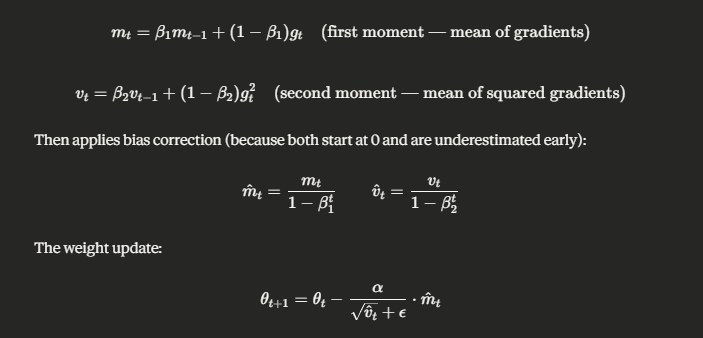

**The key insight is in the denominator:**

 sqrt(v) at t is the RMS of past gradients for that parameter. If a parameter has been getting large gradients, its effective learning rate shrinks. If it's been getting tiny gradients, its effective learning rate grows. Every parameter gets its own adaptive step size.

Adam, which stands for **Adaptive Moment Estimation**, is a popular optimization algorithm that combines the best aspects of two other extensions of stochastic gradient descent: Momentum and RMSprop (a variant of Adagrad). It's widely used in deep learning, especially for training large language models (LLMs).

The key features of Adam are:

*   **Adaptive Learning Rates**: Unlike SGD, which uses a single learning rate for all parameters, Adam computes individual adaptive learning rates for different parameters. It does this by estimating the first moment (mean) and second moment (uncentered variance) of the gradients.
*    **Momentum**: Like momentum, Adam incorporates a running average of past gradients to accelerate convergence in consistent directions and dampen oscillations.
In essence, Adam maintains two moving averages for each parameter:

*   A moving average of the gradients (similar to momentum).
*   A moving average of the squared gradients (similar to RMSprop/Adagrad).

These moving averages are then used to scale the learning rate for each parameter. Parameters with consistently large gradients will have their effective learning rate reduced, while those with small gradients will see their effective learning rate increased, allowing for more efficient optimization across different scales of parameters.

In [6]:
# Adam — the standard for fine-tuning
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Default hyperparameters — rarely need changing
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,       # α — base learning rate
    betas=(0.9, 0.999),  # β1 for gradient mean, β2 for gradient variance
    eps=1e-8,      # ε — prevents division by zero
    weight_decay=0.01    # L2 regularization — add this for fine-tuning
)

# Implementing Adam manually — exactly what PyTorch does:
def adam_step(params, grads, m, v, t, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    t += 1
    for i, (p, g) in enumerate(zip(params, grads)):
        m[i] = b1 * m[i] + (1 - b1) * g          # update gradient mean
        v[i] = b2 * v[i] + (1 - b2) * g * g       # update gradient variance

        m_hat = m[i] / (1 - b1**t)                # bias correction
        v_hat = v[i] / (1 - b2**t)                # bias correction

        p.data -= lr * m_hat / (v_hat.sqrt() + eps)  # adaptive update
    return t

# Running it:
model2 = nn.Linear(2, 1)
params = list(model2.parameters())
m = [torch.zeros_like(p) for p in params]
v = [torch.zeros_like(p) for p in params]
t = 0

for step in range(5):
    for p in params:
        if p.grad is not None: p.grad.zero_()
    pred = model2(X)
    loss = nn.MSELoss()(pred, y)
    loss.backward()
    grads = [p.grad.clone() for p in params]
    t = adam_step(params, grads, m, v, t)
    print(f"Step {step+1} | loss={loss.item():.4f} | "
          f"effective_lr_w={( (m[0]/(1-0.9**t)) / ((v[0]/(1-0.999**t)).sqrt()+1e-8) ).abs().mean().item()*1e-3:.6f}")

Step 1 | loss=1.4408 | effective_lr_w=0.001000
Step 2 | loss=1.4390 | effective_lr_w=0.001000
Step 3 | loss=1.4372 | effective_lr_w=0.001000
Step 4 | loss=1.4354 | effective_lr_w=0.001000
Step 5 | loss=1.4336 | effective_lr_w=0.001000


Comparing all three — same problem, same starting point

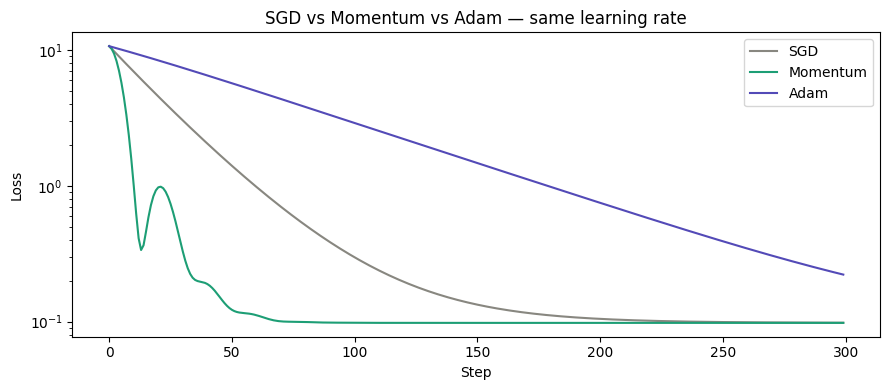

Final loss — SGD: 0.0982 | Momentum: 0.0979 | Adam: 0.2222


In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Dataset: simple linear with noise
N = 200
X = torch.randn(N, 4)
true_w = torch.tensor([1.5, -2.0, 0.5, 1.0])
y = X @ true_w + 0.3 * torch.randn(N)
y = y.unsqueeze(1)

def train(optimizer_name, lr, steps=300):
    torch.manual_seed(0)
    model = nn.Linear(4, 1)
    loss_fn = nn.MSELoss()

    optimizers = {
        'SGD':      torch.optim.SGD(model.parameters(), lr=lr),
        'Momentum': torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9),
        'Adam':     torch.optim.Adam(model.parameters(), lr=lr),
    }
    opt = optimizers[optimizer_name]
    losses = []

    for _ in range(steps):
        opt.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    return losses

# Same learning rate for all
sgd_losses  = train('SGD',      lr=0.01)
mom_losses  = train('Momentum', lr=0.01)
adam_losses = train('Adam',     lr=0.01)

plt.figure(figsize=(9, 4))
plt.plot(sgd_losses,  label='SGD',      color='#888780')
plt.plot(mom_losses,  label='Momentum', color='#1D9E75')
plt.plot(adam_losses, label='Adam',     color='#534AB7')
plt.xlabel('Step'); plt.ylabel('Loss'); plt.yscale('log')
plt.title('SGD vs Momentum vs Adam — same learning rate')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Final loss — SGD: {sgd_losses[-1]:.4f} | "
      f"Momentum: {mom_losses[-1]:.4f} | "
      f"Adam: {adam_losses[-1]:.4f}")

**Learning rate schedulers — Adam isn't the whole story**

Even with Adam, the learning rate matters and often needs to change during training. LLM fine-tuning almost always uses a warmup + cosine decay schedule.

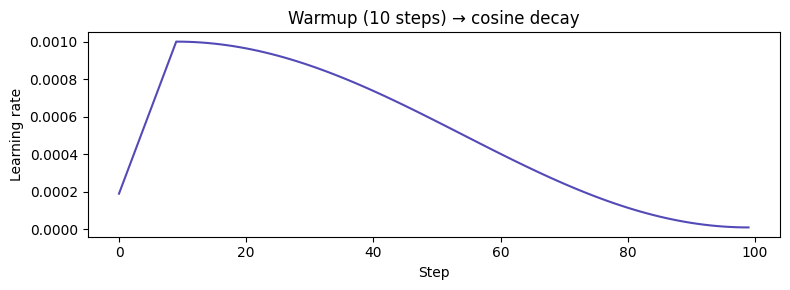

In [8]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

model = nn.Linear(4, 1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Warmup for 10 steps, then cosine decay for 90 steps
warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=10)
decay     = CosineAnnealingLR(optimizer, T_max=90, eta_min=1e-5)
scheduler = SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[10])

lrs = []
for step in range(100):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(X), y)
    loss.backward()
    optimizer.step()
    scheduler.step()        # call AFTER optimizer.step()
    lrs.append(optimizer.param_groups[0]['lr'])

plt.figure(figsize=(8, 3))
plt.plot(lrs, color='#534AB7')
plt.xlabel('Step'); plt.ylabel('Learning rate')
plt.title('Warmup (10 steps) → cosine decay')
plt.tight_layout(); plt.show()

Warmup matters because at the start of training the model's weights are random, gradients are large and unreliable, and a full learning rate would cause destructive updates. You ramp up slowly, then decay to help the model settle into a good minimum.

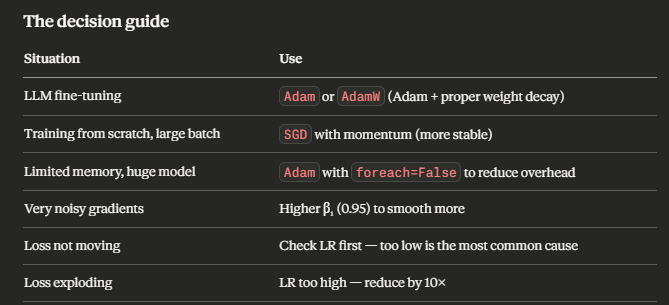

For fine-tuning, the typical starting recipe is **`AdamW`** with **`lr=2e-4`, `weight_decay=0.01`**, warmup for 3–5% of total steps, cosine decay to zero. That's the default used by most LoRA fine-tuning scripts and it works well out of the box